In [9]:
import math

import numpy as np
import matplotlib.pyplot as plt

from utils.utils import *

In [2]:
from database import init_engine, get_session, Participation, Race, Horse
from dataloader.utils import *
import utils.utils as utils

init_engine()
session = get_session()


In [3]:
def remove_anomalies(x, y, k=3):
    mean_x = np.mean(x)
    std_x = np.std(x)
    mean_y = np.mean(y)
    std_y = np.std(y)

    new_x = []
    new_y = []
    for i in range(len(x)):
        if mean_x - k * std_x < x[i] < mean_x + k * std_x and mean_y - k * std_y < y[i] < mean_y + k * std_y:
            new_x.append(x[i])
            new_y.append(y[i])

    return new_x, new_y


In [4]:
def is_new_horse(p):
    h_ps = [hp for hp in utils.remove_unranked_participants(p.horse.participations) if hp.race.date < p.race.date]
    return len(h_ps) == 0


def count_new_horses(r):
    r_ps = utils.remove_unranked_participants(r.participations)
    counter = 0
    for p in r_ps:
        if is_new_horse(p):
            counter += 1
    return counter


def count_number_of_previous_races(p):
    h_ps = [hp for hp in utils.remove_unranked_participants(p.horse.participations) if hp.race.date < p.race.date]
    return len(h_ps)


test_p = session.query(Participation).filter(Participation.horse_id == "D249").filter(Participation.race_id == "2023:32").one()
print(is_new_horse(test_p))


False


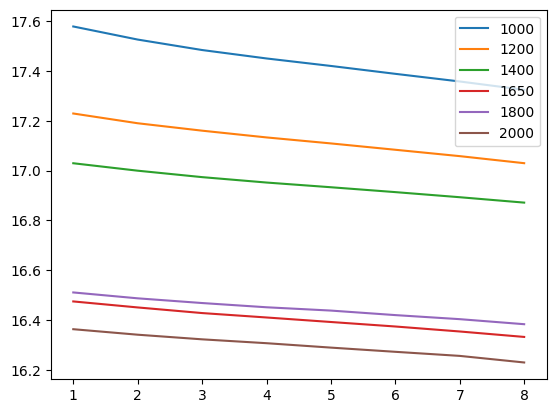

In [3]:
def get_speed_ranking_graph(distance):
    ps = (session.query(Participation).join(Race)
          .filter(Race.distance == distance).all())
    ps = remove_unranked_participants(ps)

    speeds = {}
    for p in ps:
        ranking = get_ranking_from_participation(p)
        if ranking not in speeds:
            speeds[ranking] = []
        speeds[ranking].append(calculate_speed(p))

    x_axis = []
    y_axis = []
    for ranking in sorted(speeds.keys()):
        if ranking > 8:
            continue
        x_axis.append(ranking)
        this_speeds = speeds[ranking]
        mean = np.mean(this_speeds)
        std = np.std(this_speeds)
        this_speeds = [s for s in this_speeds if mean - 3 * std < s < mean + 3 * std]
        y_axis.append(np.mean(this_speeds))

    return x_axis, y_axis

x_axis, y_axis = get_speed_ranking_graph(1000)
plt.plot(x_axis, y_axis, label="1000")
x_axis, y_axis = get_speed_ranking_graph(1200)
plt.plot(x_axis, y_axis, label="1200")
x_axis, y_axis = get_speed_ranking_graph(1400)
plt.plot(x_axis, y_axis, label="1400")
x_axis, y_axis = get_speed_ranking_graph(1650)
plt.plot(x_axis, y_axis, label="1650")
x_axis, y_axis = get_speed_ranking_graph(1800)
plt.plot(x_axis, y_axis, label="1800")
x_axis, y_axis = get_speed_ranking_graph(2000)
plt.plot(x_axis, y_axis, label="2000")
plt.legend()
plt.show()

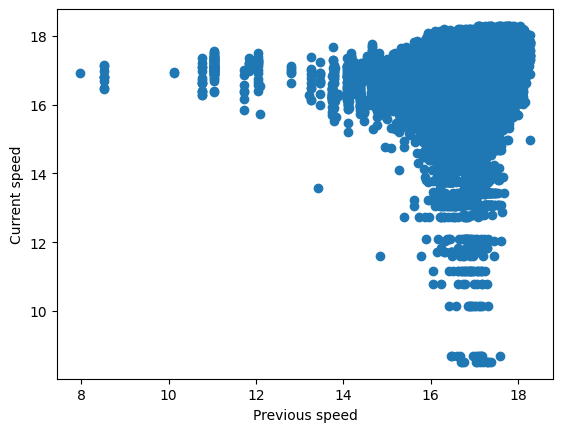

In [4]:
horses = session.query(Horse).all()
horses = [h for h in horses if len(utils.remove_unranked_participants(h.participations)) > 1]

k = 0
x_axis = []
y_axis = []
for horse in horses:
    ps = utils.remove_unranked_participants(horse.participations)
    ps.sort(key=lambda x: x.race.date)

    n = len(ps)
    for i in range(n - 1):
        for j in range(i + 1, n):
            old_speed = calculate_speed(ps[i])
            new_speed = calculate_speed(ps[j])
            if old_speed > k and new_speed > k:
                x_axis.append(old_speed)
                y_axis.append(new_speed)

plt.scatter(x_axis, y_axis)
plt.xlabel("Previous speed")
plt.ylabel("Current speed")
plt.show()

122285
10130
0.49294842416140966


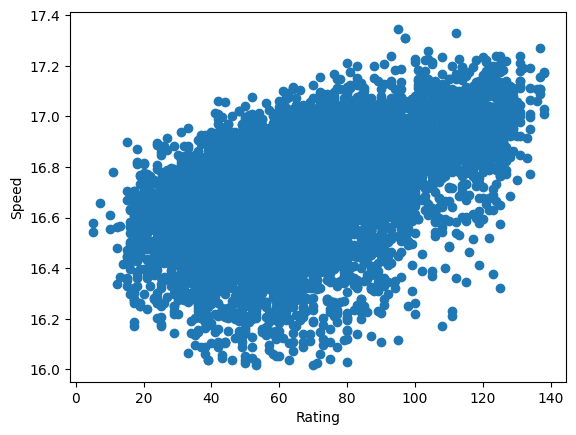

In [6]:
ps = session.query(Participation).all()
ps = utils.remove_unranked_participants(ps)

print(len(ps))
k = 0
data_points = [(p.rating, calculate_speed(p)) for p in ps if p.rating is not None and p.race.distance == 1600]
print(len(data_points))
mean = np.mean(data_points, axis=0)[1]
std = np.std(data_points, axis=0)[1]
data_points = [d for d in data_points if mean - 3 * std < d[1] < mean + 3 * std]

x_axis = list(map(lambda x: x[0], data_points))
y_axis = list(map(lambda x: x[1], data_points))
correlation_matrix = np.corrcoef(x_axis, y_axis)
r = correlation_matrix[0, 1]
print(r)

plt.scatter(x_axis, y_axis)
plt.xlabel("Rating")
plt.ylabel("Speed")
plt.show()

[]

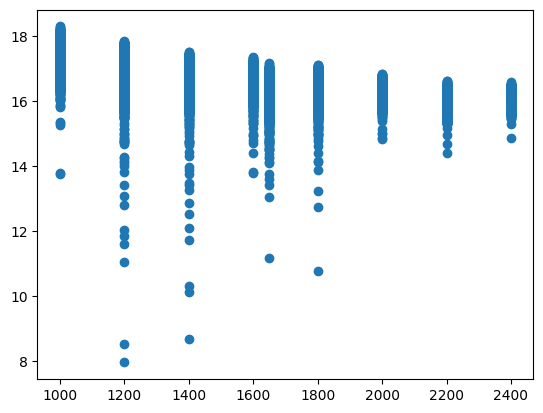

In [8]:
ps = session.query(Participation).all()
ps = utils.remove_unranked_participants(ps)

speeds = [calculate_speed(p) for p in ps]
distances = [p.race.distance for p in ps]

plt.scatter(distances, speeds)
plt.plot()

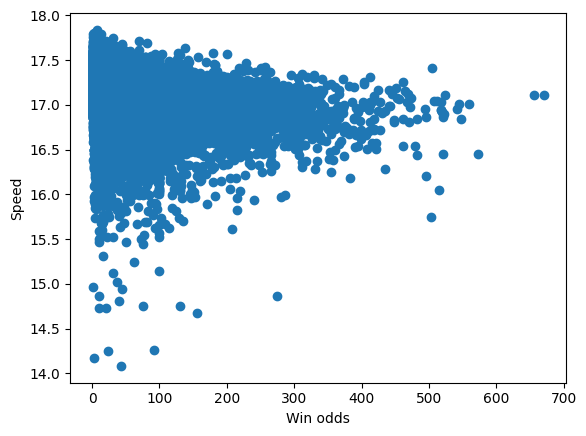

In [15]:
ps = session.query(Participation).all()
ps = utils.remove_unranked_participants(ps)

data_points = [(p.win_odds, calculate_speed(p)) for p in ps if p.race.distance == 1200 and calculate_speed(p) > 14]
x_axis = list(map(lambda x: x[0], data_points))
y_axis = list(map(lambda x: x[1], data_points))

plt.scatter(x_axis, y_axis)
plt.xlabel("Win odds")
plt.ylabel("Speed")
plt.show()

In [94]:
races = session.query(Race).all()
counter = {}
for race in races:
    if (race.distance, encode_condition(race.condition)) not in counter:
        counter[race.distance, encode_condition(race.condition)] = 0
    counter[race.distance, encode_condition(race.condition)] += 1
print(counter)

{(1600, 7): 488, (1200, 7): 2467, (1000, 7): 716, (1400, 7): 997, (1000, 8): 287, (1200, 8): 870, (1650, 8): 311, (1400, 8): 549, (1600, 8): 269, (1200, 2): 69, (1650, 7): 1193, (1800, 8): 193, (1800, 7): 561, (2000, 8): 67, (2200, 7): 102, (2200, 8): 41, (2400, 7): 23, (2000, 7): 150, (1800, 2): 12, (1650, 2): 55, (1200, 6): 109, (1400, 6): 65, (1200, 4): 6, (2000, 4): 1, (1600, 4): 3, (1400, 4): 4, (2400, 4): 1, (1000, 4): 1, (1800, 6): 19, (1000, 6): 47, (1400, 0): 24, (1200, 0): 40, (1600, 0): 16, (1800, 3): 3, (1600, 1): 1, (1200, 1): 1, (1800, 4): 1, (1650, 6): 55, (1600, 6): 37, (1650, 0): 14, (2000, 0): 4, (2000, 6): 8, (2200, 6): 5, (1000, 0): 10, (2400, 8): 8, (1200, 9): 31, (1800, 9): 6, (2400, 6): 4, (2200, 0): 2, (1800, 0): 10, (1200, 3): 11, (1200, 5): 3, (1600, 5): 1, (1650, 9): 12, (1650, 3): 10, (2400, 0): 1, (1650, 5): 1, (1650, 4): 1}


1: 142, 2: 67, 3: 86, 4: 100, 5: 98, 6: 86, 7: 87, 8: 104, 9: 96, 10: 102, 11: 101, 12: 87, 13: 57, 14: 46, 15: 23, 16: 14, 17: 7, 18: 2, 19: 3, 23: 1, 

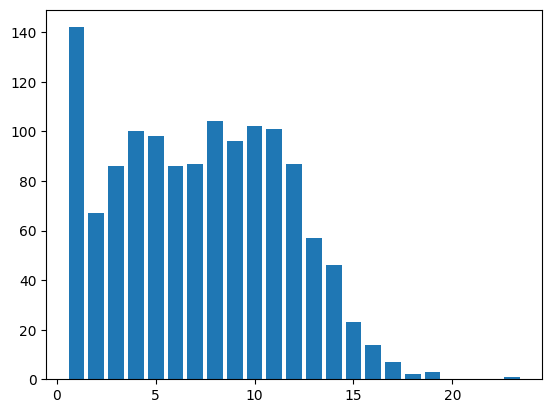

In [105]:
horses = session.query(Horse).all()
counter = {}
for horse in horses:
    ps = utils.remove_unranked_participants(horse.participations)
    ps = [p for p in ps if p.race.season == 2014]
    n = len(ps)
    if n not in counter:
        counter[n] = 0
    counter[n] += 1

keys = list(counter.keys())
keys.sort()
x_axis = []
y_axis = []
for key in keys:
    if key == 0:
        continue
    x_axis.append(key)
    y_axis.append(counter[key])
    print(f"{key}: {counter[key]}", end=", ")

plt.bar(x_axis, y_axis)
plt.xlabel("Number of races")
plt.show()

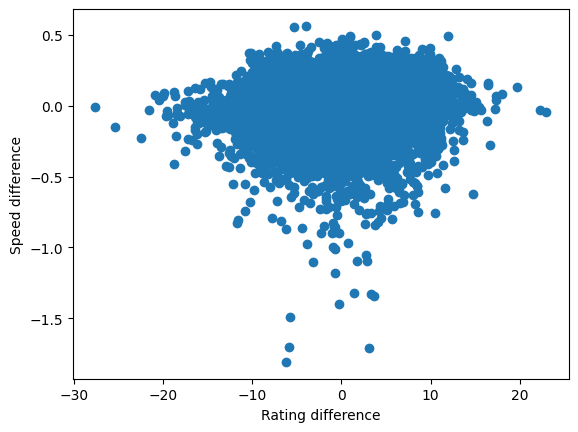

In [23]:
races = session.query(Race).filter(Race.distance==1000).all()
x_axis = []
y_axis = []
for race in races:
    ps = utils.remove_unranked_participants(race.participations)
    speeds = list(map(calculate_speed, ps))
    mean_speed = np.mean(speeds)
    std_speed = np.std(speeds)
    all_rating = [p.rating for p in ps if p.rating is not None]
    mean_rating = np.mean(all_rating)
    for p in ps:
        speed = calculate_speed(p)
        if p.rating is None or (speed - mean_speed) < -3.0:
            continue
        x_axis.append(float(p.rating - mean_rating))
        y_axis.append(float(speed - mean_speed))

plt.scatter(x_axis, y_axis)
plt.xlabel("Rating difference")
plt.ylabel("Speed difference")
plt.show()

In [44]:
races = session.query(Race).filter(Race.date > datetime(2019, 9, 1).date()).filter(Race.date < datetime(2020, 9, 1).date()).all()
specific_counter = {}
for race in races:
    this_counter = 0
    ps = utils.remove_unranked_participants(race.participations)
    for p in ps:
        if p.rating is None:
            this_counter += 1
    if this_counter not in specific_counter:
        specific_counter[this_counter] = 0
    specific_counter[this_counter] += 1

keys = list(specific_counter.keys())
keys.sort()
print("Key: number of horses with no rating in race. Value: number of races")
for key in keys:
    print(f"{key}: {specific_counter[key]}", end=", ")

Key: number of horses with no rating in race. Value: number of races
0: 727, 1: 76, 2: 6, 3: 2, 4: 1, 5: 2, 6: 1, 9: 2, 10: 1, 

In [66]:
races = session.query(Race).filter(Race.date > datetime(2019, 9, 1).date()).filter(Race.date < datetime(2020, 9, 1).date()).all()
specific_counter = {}
target = set()
for race in races:
    this_counter = 0
    ps = utils.remove_unranked_participants(race.participations)
    for p in ps:
        if is_new_horse(p):
            this_counter += 1
    if this_counter not in specific_counter:
        specific_counter[this_counter] = 0
    specific_counter[this_counter] += 1

keys = list(specific_counter.keys())
keys.sort()
print("Key: number of new horses in race. Value: number of races")
for key in keys:
    print(f"{key}: {specific_counter[key]}", end=", ")


Key: number of new horses in race. Value: number of races
0: 537, 1: 164, 2: 64, 3: 26, 4: 12, 5: 8, 6: 5, 8: 2, 

In [89]:
ps = utils.remove_unranked_participants(session.query(Participation).join(Race).filter(Race.date > datetime(2015, 9, 1).date()).filter(Race.date < datetime(2020, 9, 1).date()).all())
ps = [p for p in ps if count_new_horses(p.race) <= 3]
first_place = 0
top_3 = 0
for p in ps:
    if is_new_horse(p):
        if get_ranking_from_participation(p) == 1:
            first_place += 1
            top_3 += 1
        elif get_ranking_from_participation(p) <= 3:
            top_3 += 1
print(first_place)
print(top_3)
print(len(ps))
print(f"{first_place * 100 / len(ps):.2f}%")
print(f"{top_3 * 100/ len(ps):.2f}%")

79
226
47774
0.17%
0.47%


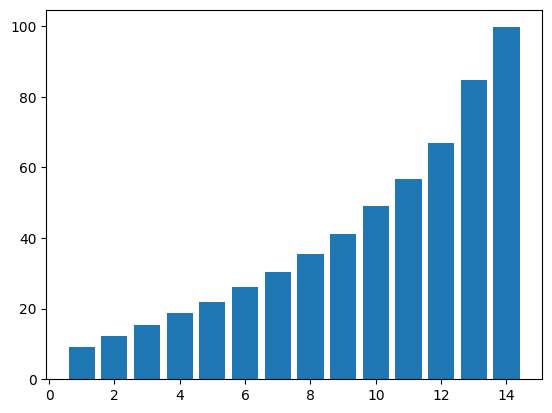

In [97]:
ps = utils.remove_unranked_participants(session.query(Participation).all())

win_odds = {}
for p in ps:
    ranking = get_ranking_from_participation(p)
    if ranking not in win_odds:
        win_odds[ranking] = []
    win_odds[ranking].append(float(p.win_odds))

for win_odd in win_odds:
    win_odds[win_odd] = float(np.mean(win_odds[win_odd]))

plt.bar(win_odds.keys(), win_odds.values())
plt.xlabel("Ranking")
plt.ylabel("Win Odds")
plt.show()

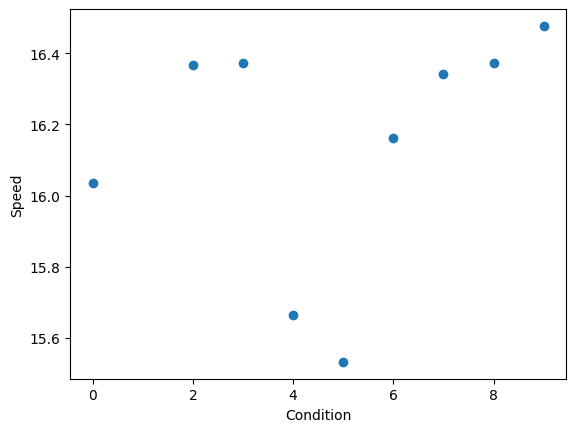

In [13]:
# average speed against condition

ps = utils.remove_unranked_participants(session.query(Participation).join(Race).filter(Race.distance == 1000).all())
speeds = {}

for p in ps:
    condition = encode_condition(p.race.condition)
    if condition not in speeds:
        speeds[condition] = []
    speeds[condition].append(float(calculate_speed(p)))

for condition in speeds:
    speeds[condition] = float(np.mean(speeds[condition]))

plt.scatter(speeds.keys(), speeds.values())
plt.xlabel("Condition")
plt.ylabel("Speed")
plt.show()


dict_keys([4, 3, 5, 2, 0.3, 6, 1, 0.1])


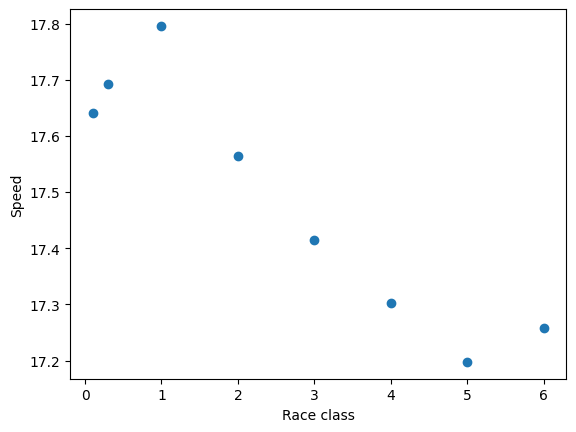

In [38]:
ps = utils.remove_unranked_participants(session.query(Participation).join(Race).filter(Race.distance == 1000).all())

speeds = {}

for p in ps:
    race_class = convert_race_class(p.race.race_class)
    if race_class not in speeds:
        speeds[race_class] = []
    speeds[race_class].append(float(calculate_speed(p)))

for race_class in speeds:
    speeds[race_class] = float(np.mean(speeds[race_class]))

print(speeds.keys())
plt.scatter(speeds.keys(), speeds.values())
plt.xlabel("Race class")
plt.ylabel("Speed")
plt.show()


a=4.380575705649209e-11, b=-1.8558351783455107e-07, c=0.0001965584384634294, d=16.83525862980849


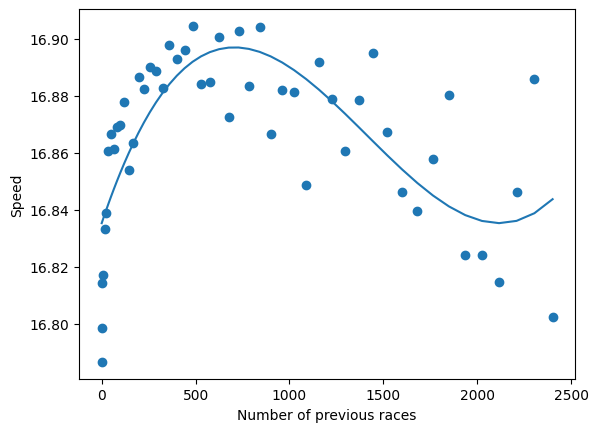

In [52]:
ps = utils.remove_unranked_participants(session.query(Participation).join(Race).filter(Race.distance == 1400).all())
speeds = {}
k = 50

for p in ps:
    t = count_number_of_previous_races(p)
    if t not in speeds:
        speeds[t] = []
    speeds[t].append(float(calculate_speed(p)))

for t in speeds:
    speeds[t] = float(np.mean(speeds[t]))

speed_keys = speeds.keys()
x_axis = [n * n for n in speed_keys if n < k]
y_axis = [speeds[n] for n in speed_keys if n < k]
line_x = [x * x for x in range(k)]
a, b, c, d = np.polyfit(x_axis, y_axis, 3)
line_y = [float(a * x ** 3 + b * x ** 2 + c * x + d) for x in line_x]
print(f"a={a}, b={b}, c={c}, d={d}")

plt.scatter(x_axis, y_axis)
plt.plot(line_x, line_y)
plt.xlabel("Number of previous races")
plt.ylabel("Speed")
plt.show()  


21425
21785
360


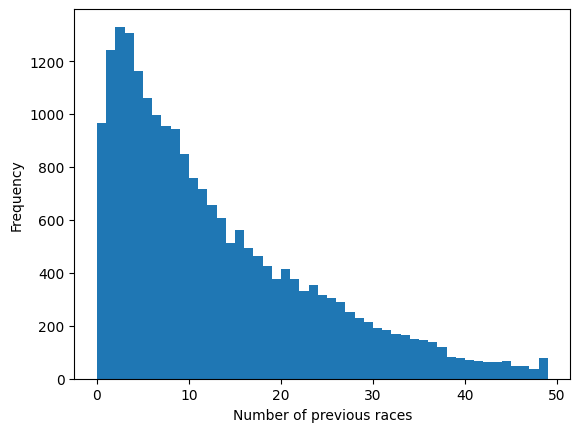

965
1243
1330
1305
1162
1059


In [24]:
ps = utils.remove_unranked_participants(session.query(Participation).join(Race).filter(Race.distance == 1400).all())
number_of_previous_races = []
for p in ps:
    number_of_previous_races.append(count_number_of_previous_races(p))

normal_range = [p for p in number_of_previous_races if p < 60]
normal_length = len(normal_range)
total_length = len(number_of_previous_races)
print(normal_length)
print(total_length)
print(total_length - normal_length)
maximum = max(normal_range)
plt.hist(normal_range, bins=maximum)
plt.xlabel("Number of previous races")
plt.ylabel("Frequency")
plt.show()
print(len([r for r in normal_range if r == 0]))
print(len([r for r in normal_range if r == 1]))
print(len([r for r in normal_range if r == 2]))
print(len([r for r in normal_range if r == 3]))
print(len([r for r in normal_range if r == 4]))
print(len([r for r in normal_range if r == 5]))

In [ ]:
# find speed against previous win odds
# find ranking against rating difference
# find ranking against rating update

In [ ]:
# find horse weight against speeed
# find gear weight against speed

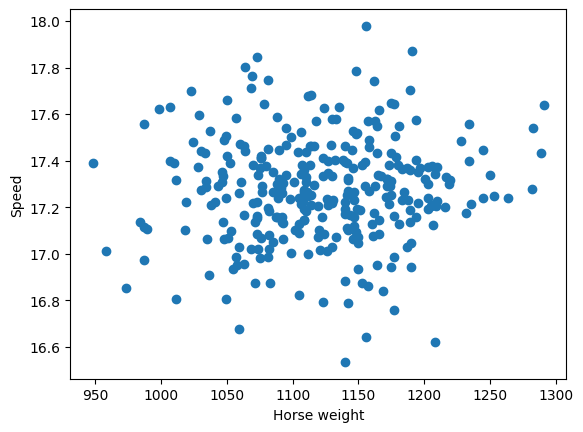

In [33]:
ps = utils.remove_unranked_participants(session.query(Participation).join(Race).filter(Race.distance == 1000).filter(Participation.rating == 50).all())

x_axis = []
y_axis = []

for p in ps:
    x_axis.append(p.horse_weight)
    y_axis.append(calculate_speed(p))

x_axis, y_axis = remove_anomalies(x_axis, y_axis)
plt.scatter(x_axis, y_axis)
plt.xlabel("Horse weight")
plt.ylabel("Speed")
plt.show()

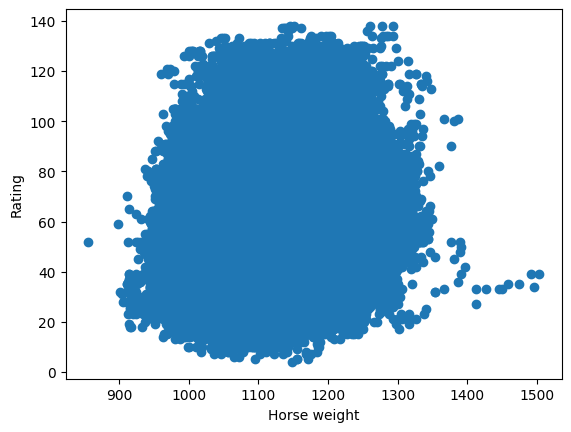

In [35]:
ps = utils.remove_unranked_participants(session.query(Participation).all())

x_axis = [p.horse_weight for p in ps if p.rating is not None]
y_axis = [p.rating for p in ps if p.rating is not None]

plt.scatter(x_axis, y_axis)
plt.xlabel("Horse weight")
plt.ylabel("Rating")
plt.show()

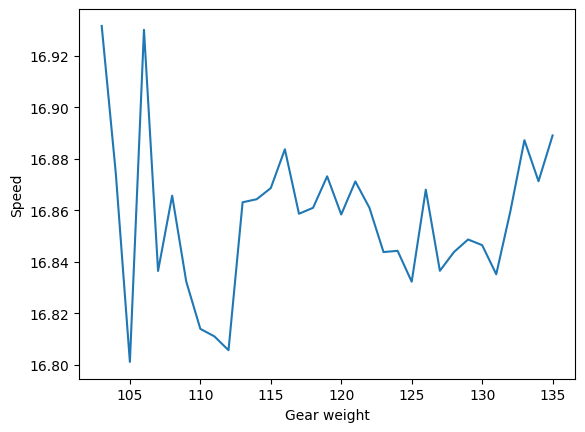

In [17]:
ps = utils.remove_unranked_participants(session.query(Participation).join(Race).filter(Race.distance == 1400).all())

speeds = {}

for p in ps:
    if p.gear_weight not in speeds:
        speeds[p.gear_weight] = []
    speeds[p.gear_weight].append(float(calculate_speed(p)))

for gear_weight in speeds:
    speeds[gear_weight] = float(np.mean(speeds[gear_weight]))

x_axis = list(speeds.keys())
x_axis.sort()
y_axis = [speeds[gear_weight] for gear_weight in x_axis]
plt.plot(x_axis, y_axis)
plt.xlabel("Gear weight")
plt.ylabel("Speed")
plt.show()